# 02 Performance Comparison

This notebook reproduces the cortex performance comparison for imputation and clustering. It embeds the small metric helpers from `utils.py`, so the notebook is self-contained.

In [1]:
from __future__ import annotations

import os
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyro
import torch
from sklearn.cluster import KMeans
from sklearn.decomposition import FactorAnalysis
from sklearn.metrics import adjusted_rand_score as ARI
from sklearn.metrics import normalized_mutual_info_score as NMI
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

from FA import FA
from ZIFA import ZIFA

warnings.filterwarnings("ignore")

PROJECT_DIR = Path(".")
DATA_DIR = Path("datasets/cortex/datasets")
RESULT_DIR = Path("../results/scPI")
FIGURE_DIR = RESULT_DIR / "figures"
PERFORMANCE_IMPUTATION_VALUES_CSV = RESULT_DIR / "performance_imputation_values.csv"
PERFORMANCE_CLUSTERING_VALUES_CSV = RESULT_DIR / "performance_clustering_values.csv"
PERFORMANCE_THRESHOLDS_CSV = RESULT_DIR / "performance_thresholds.csv"
PERFORMANCE_IMPUTATION_SUMMARY_CSV = RESULT_DIR / "performance_imputation_summary.csv"
PERFORMANCE_CLUSTERING_SUMMARY_CSV = RESULT_DIR / "performance_clustering_summary.csv"

for path in [RESULT_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SEED = 2026
K = 10
N_REPEAT = 10
N_CELLTYPE = 7

INIT_EPOCHS_IMPUTATION = 2000
INIT_EPOCHS_CLUSTERING = 1000
MAX_EPOCHS = 100000

np.random.seed(SEED)
torch.manual_seed(SEED)


/home/ztanag/miniconda3/envs/sctm/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def cluster_scores(latent_space, K, labels_true):
    labels_pred = KMeans(K, n_init=20, random_state=SEED).fit_predict(latent_space)
    return [
        silhouette_score(latent_space, labels_true),
        NMI(labels_true, labels_pred),
        ARI(labels_true, labels_pred),
    ]


def imputation_error(X_mean, X, X_zero, i, j, ix):
    all_index = i[ix], j[ix]
    x, y = X_mean[all_index], X[all_index]
    return np.median(np.abs(x - y))


In [3]:
def load_cortex_data():
    expression_path = DATA_DIR / "expression_mRNA_17-Aug-2014.txt"
    if not expression_path.exists():
        raise FileNotFoundError(f"Missing cortex expression file: {expression_path}")

    X = pd.read_csv(expression_path, sep="	", low_memory=False).T
    clusters = np.array(X[7], dtype=str)[2:]
    _, labels = np.unique(clusters, return_inverse=True)

    X = X.loc[:, 10:]
    X = X.drop(X.index[0])
    expression = np.array(X, dtype=int)[1:]

    selected = np.std(expression, axis=0).argsort()[-558:][::-1]
    expression = expression[:, selected]

    X_train, X_test, label_train, label_test = train_test_split(
        expression, labels, random_state=0
    )

    rng = np.random.default_rng(SEED)
    X_zero_counts = np.array(X_train, dtype=np.float32, copy=True)
    i, j = np.nonzero(X_zero_counts)
    ix = rng.choice(np.arange(len(i)), int(np.floor(0.1 * len(i))), replace=False)
    X_zero_counts[i[ix], j[ix]] = 0.0

    return {
        "X_true_counts": np.asarray(X_train, dtype=np.float32),
        "X_zero_counts": X_zero_counts,
        "X_zero_log": np.log1p(X_zero_counts).astype(np.float32),
        "expression_train_log": np.log1p(np.asarray(X_train, dtype=np.float32)),
        "label_train": np.asarray(label_train),
        "i": i,
        "j": j,
        "ix": ix,
    }


data = load_cortex_data()
X_true_counts = data["X_true_counts"]
X_zero_counts = data["X_zero_counts"]
X_zero = data["X_zero_log"]
expression_train = data["expression_train_log"]
label_train = data["label_train"]
i = data["i"]
j = data["j"]
ix = data["ix"]
N, D = X_zero.shape

print("X_zero:", X_zero.shape)
print("expression_train:", expression_train.shape)
print("labels:", np.unique(label_train), "n_celltype=", len(np.unique(label_train)))
print("Held-out nonzero entries:", len(ix))


X_zero: (2253, 558)
expression_train: (2253, 558)
labels: [0 1 2 3 4 5 6] n_celltype= 7
Held-out nonzero entries: 88971


In [4]:
import contextlib
import io

def reset_random_state(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    pyro.clear_param_store()


def fa_display_name(method: str) -> str:
    return {"FA": "FA", "VI": "FA-VI", "Amortized": "FA-AVI"}[method]


def zifa_display_name(method: str) -> str:
    return {"ZIFA": "ZIFA", "VI": "ZIFA-VI", "Amortized": "ZIFA-AVI"}[method]



def _loss_value(result: dict):
    if result is None:
        return None
    if "loss" in result:
        return float(result["loss"])
    if "logllh" in result:
        return float(result["logllh"])
    return None


def _start_loss_value(result: dict):
    if result is None:
        return None
    for key in ["losses", "step_losses"]:
        values = result.get(key)
        if values:
            return float(values[0])
    return _loss_value(result)


def _format_loss(value):
    return "NA" if value is None else f"{value:.6f}"


def fit_with_summary(model, Y, label: str):
    start = time.time()
    print(f"{label}: training started")
    with contextlib.redirect_stdout(io.StringIO()):
        model.fit(Y)
    elapsed = time.time() - start
    start_loss = _start_loss_value(model.result)
    finish_loss = _loss_value(model.result)
    print(
        f"{label}: start loss={_format_loss(start_loss)}, "
        f"finish loss={_format_loss(finish_loss)}, time={elapsed:.2f}s"
    )
    return elapsed

def initialize_loss_threshold(family: str, X: np.ndarray, epochs: int) -> float:
    reset_random_state(SEED)
    if family == "FA":
        model = FA(K=K, method="amortized", loss_threshold=float("-inf"), max_epochs=epochs)
    elif family == "ZIFA":
        model = ZIFA(K=K, method="pyro", inference="amortized", loss_threshold=float("-inf"), max_epochs=epochs)
    else:
        raise ValueError(f"Unknown family: {family}")
    fit_with_summary(model, X, f"{family} threshold warmup ({epochs} epochs)")
    loss = float(model.result["loss"])
    threshold = float(np.floor(loss))
    print(f"{family} threshold: finish loss={loss:.4f}, threshold={threshold:.4f}")
    return threshold


def dense_reconstruction(result: dict, D: int) -> np.ndarray:
    A = result["A"]
    Z = result["latent"]
    mu = result.get("mu", result.get("mus"))
    mu = np.asarray(mu).reshape([1, -1])
    return np.exp(Z @ A.T + mu.reshape([1, A.shape[0]])) - 1


def _result_values_to_frame(results: dict, family: str, metric_keys: list[str]) -> pd.DataFrame:
    rows = []
    for method, values in results.items():
        display = fa_display_name(method) if family == "FA" else zifa_display_name(method)
        n = len(values.get(metric_keys[0], []))
        for repeat in range(n):
            row = {"Family": family, "MethodKey": method, "Method": display, "Repeat": repeat + 1}
            for key in metric_keys:
                row[key] = values[key][repeat]
            if "time" in values:
                row["time"] = values["time"][repeat]
            rows.append(row)
    return pd.DataFrame(rows)


def save_performance_results() -> None:
    imputation_df = pd.concat(
        [
            _result_values_to_frame(results_imputation_fa, "FA", ["error"]),
            _result_values_to_frame(results_imputation_zifa, "ZIFA", ["error"]),
        ],
        ignore_index=True,
    )
    clustering_df = pd.concat(
        [
            _result_values_to_frame(results_clustering_fa, "FA", ["ASW", "NMI", "ARI"]),
            _result_values_to_frame(results_clustering_zifa, "ZIFA", ["ASW", "NMI", "ARI"]),
        ],
        ignore_index=True,
    )
    thresholds_df = pd.DataFrame(
        [
            {"Name": "fa_imputation", "Value": fa_imputation_threshold},
            {"Name": "zifa_imputation", "Value": zifa_imputation_threshold},
            {"Name": "fa_clustering", "Value": fa_clustering_threshold},
            {"Name": "zifa_clustering", "Value": zifa_clustering_threshold},
        ]
    )
    imputation_df.to_csv(PERFORMANCE_IMPUTATION_VALUES_CSV, index=False)
    clustering_df.to_csv(PERFORMANCE_CLUSTERING_VALUES_CSV, index=False)
    thresholds_df.to_csv(PERFORMANCE_THRESHOLDS_CSV, index=False)
    print("Saved performance CSV results:")
    print(" ", PERFORMANCE_IMPUTATION_VALUES_CSV)
    print(" ", PERFORMANCE_CLUSTERING_VALUES_CSV)
    print(" ", PERFORMANCE_THRESHOLDS_CSV)


def _frame_to_results(df: pd.DataFrame, family: str, metrics: list[str]) -> dict:
    results = {}
    for method_key, sub in df[df["Family"] == family].groupby("MethodKey", sort=False):
        sub = sub.sort_values("Repeat")
        results[method_key] = {metric: sub[metric].astype(float).tolist() for metric in metrics}
        if "time" in sub.columns:
            results[method_key]["time"] = sub["time"].astype(float).tolist()
    return results


def load_performance_results() -> tuple[pd.DataFrame, pd.DataFrame]:
    missing = [
        path for path in [PERFORMANCE_IMPUTATION_VALUES_CSV, PERFORMANCE_CLUSTERING_VALUES_CSV]
        if not path.exists()
    ]
    if missing:
        raise FileNotFoundError(f"Missing saved result CSV files: {missing}. Run the computation cells first.")
    imputation_df = pd.read_csv(PERFORMANCE_IMPUTATION_VALUES_CSV)
    clustering_df = pd.read_csv(PERFORMANCE_CLUSTERING_VALUES_CSV)
    return imputation_df, clustering_df


def assign_loaded_performance_results() -> None:
    global results_imputation_fa, results_imputation_zifa
    global results_clustering_fa, results_clustering_zifa
    global fa_imputation_threshold, zifa_imputation_threshold
    global fa_clustering_threshold, zifa_clustering_threshold

    imputation_df, clustering_df = load_performance_results()
    results_imputation_fa = _frame_to_results(imputation_df, "FA", ["error"])
    results_imputation_zifa = _frame_to_results(imputation_df, "ZIFA", ["error"])
    results_clustering_fa = _frame_to_results(clustering_df, "FA", ["ASW", "NMI", "ARI"])
    results_clustering_zifa = _frame_to_results(clustering_df, "ZIFA", ["ASW", "NMI", "ARI"])

    if PERFORMANCE_THRESHOLDS_CSV.exists():
        thresholds = pd.read_csv(PERFORMANCE_THRESHOLDS_CSV).set_index("Name")["Value"].to_dict()
        fa_imputation_threshold = thresholds.get("fa_imputation")
        zifa_imputation_threshold = thresholds.get("zifa_imputation")
        fa_clustering_threshold = thresholds.get("fa_clustering")
        zifa_clustering_threshold = thresholds.get("zifa_clustering")
    print("Loaded performance CSV results:")
    print(" ", PERFORMANCE_IMPUTATION_VALUES_CSV)
    print(" ", PERFORMANCE_CLUSTERING_VALUES_CSV)


## Imputation Experiments

Runs all methods for imputation and records median absolute imputation error plus runtime.


In [5]:
def run_fa_imputation(loss_threshold: float) -> dict:
    results = {
        "FA": {"error": [], "time": []},
        "VI": {"error": [], "time": []},
        "Amortized": {"error": [], "time": []},
    }

    print("Running FA imputation...")
    for repeat in range(N_REPEAT):
        start = time.time()
        alg = FactorAnalysis(n_components=K, random_state=repeat)
        alg.fit(X_zero)
        Z = alg.transform(X_zero)
        X_impu = np.exp(Z @ alg.components_ + alg.mean_.reshape([1, D])) - 1
        err = imputation_error(X_impu, X_true_counts, X_zero_counts, i, j, ix)
        elapsed = time.time() - start
        results["FA"]["error"].append(float(err))
        results["FA"]["time"].append(float(elapsed))
        print(f"  FA repeat {repeat + 1}: error={err:.6f}, time={elapsed:.2f}s")

    print("Running FA-VI and FA-AVI imputation...")
    for repeat in range(N_REPEAT):
        for method, inference in [("VI", "vi"), ("Amortized", "amortized")]:
            reset_random_state(1234 + repeat)
            start = time.time()
            model = FA(K=K, method=inference, loss_threshold=loss_threshold, max_epochs=MAX_EPOCHS)
            elapsed = fit_with_summary(model, X_zero, f"{fa_display_name(method)} imputation repeat {repeat + 1}")
            X_impu = dense_reconstruction(model.result, D)
            err = imputation_error(X_impu, X_true_counts, X_zero_counts, i, j, ix)
            results[method]["error"].append(float(err))
            results[method]["time"].append(float(elapsed))
            print(f"  {fa_display_name(method)} repeat {repeat + 1}: error={err:.6f}, time={elapsed:.2f}s")

    return results


def run_zifa_imputation(loss_threshold: float) -> dict:
    results = {
        "ZIFA": {"error": [], "time": []},
        "VI": {"error": [], "time": []},
        "Amortized": {"error": [], "time": []},
    }

    non_zero_cols = ~(np.abs(X_zero) < 1e-6).all(axis=0)
    zero_cols = ~non_zero_cols
    X_zero_filtered = X_zero[:, non_zero_cols]

    print("Running ZIFA imputation...")
    for repeat in range(N_REPEAT):
        reset_random_state(1234 + repeat)
        start = time.time()
        model = ZIFA(K=K, method="classic")
        elapsed = fit_with_summary(model, X_zero_filtered, f"ZIFA imputation repeat {repeat + 1}")
        X_impu_filtered = dense_reconstruction(model.result, X_zero_filtered.shape[1])
        X_impu = np.zeros_like(X_true_counts, dtype=np.float64)
        X_impu[:, non_zero_cols] = X_impu_filtered
        X_impu[:, zero_cols] = 0.0
        err = imputation_error(X_impu, X_true_counts, X_zero_counts, i, j, ix)
        elapsed = time.time() - start
        results["ZIFA"]["error"].append(float(err))
        results["ZIFA"]["time"].append(float(elapsed))
        print(f"  ZIFA repeat {repeat + 1}: error={err:.6f}, time={elapsed:.2f}s")

    print("Running ZIFA-VI and ZIFA-AVI imputation...")
    for repeat in range(N_REPEAT):
        for method, inference in [("VI", "vi"), ("Amortized", "amortized")]:
            reset_random_state(1234 + repeat)
            start = time.time()
            model = ZIFA(K=K, method="pyro", inference=inference, loss_threshold=loss_threshold, max_epochs=MAX_EPOCHS)
            elapsed = fit_with_summary(model, X_zero, f"{zifa_display_name(method)} imputation repeat {repeat + 1}")
            X_impu = dense_reconstruction(model.result, D)
            err = imputation_error(X_impu, X_true_counts, X_zero_counts, i, j, ix)
            results[method]["error"].append(float(err))
            results[method]["time"].append(float(elapsed))
            print(f"  {zifa_display_name(method)} repeat {repeat + 1}: error={err:.6f}, time={elapsed:.2f}s")

    return results


In [6]:
fa_imputation_threshold = initialize_loss_threshold("FA", X_zero, INIT_EPOCHS_IMPUTATION)
zifa_imputation_threshold = initialize_loss_threshold("ZIFA", X_zero, INIT_EPOCHS_IMPUTATION)

results_imputation_fa = run_fa_imputation(fa_imputation_threshold)
results_imputation_zifa = run_zifa_imputation(zifa_imputation_threshold)


FA threshold warmup (2000 epochs): training started
FA threshold warmup (2000 epochs): start loss=1945.512082, finish loss=634.681287, time=347.17s
FA threshold: finish loss=634.6813, threshold=634.0000
ZIFA threshold warmup (2000 epochs): training started
ZIFA threshold warmup (2000 epochs): start loss=2071.343394, finish loss=532.534339, time=440.30s
ZIFA threshold: finish loss=532.5343, threshold=532.0000
Running FA imputation...
  FA repeat 1: error=2.505469, time=2.66s
  FA repeat 2: error=2.504953, time=3.40s
  FA repeat 3: error=2.506474, time=1.75s
  FA repeat 4: error=2.506216, time=1.64s
  FA repeat 5: error=2.503741, time=2.70s
  FA repeat 6: error=2.505994, time=1.51s
  FA repeat 7: error=2.506900, time=1.68s
  FA repeat 8: error=2.505038, time=0.88s
  FA repeat 9: error=2.507300, time=1.09s
  FA repeat 10: error=2.505528, time=0.64s
Running FA-VI and FA-AVI imputation...
FA-VI imputation repeat 1: training started
FA-VI imputation repeat 1: start loss=2073.207974, finish l

In [7]:
def imputation_summary(results_fa: dict, results_zifa: dict) -> pd.DataFrame:
    rows = []
    for method, values in results_fa.items():
        rows.append({
            "Method": fa_display_name(method),
            "Metric": "Imputation Error",
            "Mean": np.mean(values["error"]),
            "Median": np.median(values["error"]),
            "Std": np.std(values["error"], ddof=1),
            "Mean time (s)": np.mean(values.get("time", [np.nan])),
        })
    for method, values in results_zifa.items():
        rows.append({
            "Method": zifa_display_name(method),
            "Metric": "Imputation Error",
            "Mean": np.mean(values["error"]),
            "Median": np.median(values["error"]),
            "Std": np.std(values["error"], ddof=1),
            "Mean time (s)": np.mean(values.get("time", [np.nan])),
        })
    df = pd.DataFrame(rows)
    return df

imputation_summary_df = imputation_summary(results_imputation_fa, results_imputation_zifa)
imputation_summary_df.to_csv(PERFORMANCE_IMPUTATION_SUMMARY_CSV, index=False)
imputation_summary_df.head()


,Method,Metric,Mean,Median,Std,Mean time (s)
0,FA,Imputation Error,2.505761,2.505761,0.001045,1.795136
1,FA-VI,Imputation Error,2.509746,2.509213,0.003184,507.987484
2,FA-AVI,Imputation Error,2.500896,2.502389,0.014848,444.382701
3,ZIFA,Imputation Error,2.176127,2.176127,0.000000,15608.076618
4,ZIFA-VI,Imputation Error,2.168576,2.168203,0.002477,275.472785


## Clustering Experiments

Runs all methods for clustering on the log1p training expression matrix and records ASW, NMI, ARI, and runtime.

In [8]:
def run_fa_clustering(loss_threshold: float) -> dict:
    results = {
        "FA": {"ASW": [], "NMI": [], "ARI": [], "time": []},
        "VI": {"ASW": [], "NMI": [], "ARI": [], "time": []},
        "Amortized": {"ASW": [], "NMI": [], "ARI": [], "time": []},
    }

    print("Running FA clustering...")
    for repeat in range(N_REPEAT):
        start = time.time()
        alg = FactorAnalysis(n_components=K, random_state=repeat)
        alg.fit(expression_train)
        latent = alg.transform(expression_train)
        elapsed = time.time() - start
        scores = cluster_scores(latent, N_CELLTYPE, label_train)
        for metric, value in zip(["ASW", "NMI", "ARI"], scores):
            results["FA"][metric].append(float(value))
        results["FA"]["time"].append(float(elapsed))
        print(f"  FA repeat {repeat + 1}: ASW={scores[0]:.4f}, NMI={scores[1]:.4f}, ARI={scores[2]:.4f}, time={elapsed:.2f}s")

    print("Running FA-VI and FA-AVI clustering...")
    for repeat in range(N_REPEAT):
        for method, inference in [("VI", "vi"), ("Amortized", "amortized")]:
            reset_random_state(1234 + repeat)
            start = time.time()
            model = FA(K=K, method=inference, loss_threshold=loss_threshold, max_epochs=MAX_EPOCHS)
            elapsed = fit_with_summary(model, expression_train, f"{fa_display_name(method)} clustering repeat {repeat + 1}")
            scores = cluster_scores(model.latent, N_CELLTYPE, label_train)
            for metric, value in zip(["ASW", "NMI", "ARI"], scores):
                results[method][metric].append(float(value))
            results[method]["time"].append(float(elapsed))
            print(f"  {fa_display_name(method)} repeat {repeat + 1}: ASW={scores[0]:.4f}, NMI={scores[1]:.4f}, ARI={scores[2]:.4f}, time={elapsed:.2f}s")

    return results


def run_zifa_clustering(loss_threshold: float) -> dict:
    results = {
        "ZIFA": {"ASW": [], "NMI": [], "ARI": [], "time": []},
        "VI": {"ASW": [], "NMI": [], "ARI": [], "time": []},
        "Amortized": {"ASW": [], "NMI": [], "ARI": [], "time": []},
    }

    print("Running ZIFA clustering...")
    for repeat in range(N_REPEAT):
        reset_random_state(1234 + repeat)
        start = time.time()
        model = ZIFA(K=K, method="classic")
        elapsed = fit_with_summary(model, expression_train, f"ZIFA clustering repeat {repeat + 1}")
        scores = cluster_scores(model.latent, N_CELLTYPE, label_train)
        for metric, value in zip(["ASW", "NMI", "ARI"], scores):
            results["ZIFA"][metric].append(float(value))
        results["ZIFA"]["time"].append(float(elapsed))
        print(f"  ZIFA repeat {repeat + 1}: ASW={scores[0]:.4f}, NMI={scores[1]:.4f}, ARI={scores[2]:.4f}, time={elapsed:.2f}s")

    print("Running ZIFA-VI and ZIFA-AVI clustering...")
    for repeat in range(N_REPEAT):
        for method, inference in [("VI", "vi"), ("Amortized", "amortized")]:
            reset_random_state(1234 + repeat)
            start = time.time()
            model = ZIFA(K=K, method="pyro", inference=inference, loss_threshold=loss_threshold, max_epochs=MAX_EPOCHS)
            elapsed = fit_with_summary(model, expression_train, f"{zifa_display_name(method)} clustering repeat {repeat + 1}")
            scores = cluster_scores(model.latent, N_CELLTYPE, label_train)
            for metric, value in zip(["ASW", "NMI", "ARI"], scores):
                results[method][metric].append(float(value))
            results[method]["time"].append(float(elapsed))
            print(f"  {zifa_display_name(method)} repeat {repeat + 1}: ASW={scores[0]:.4f}, NMI={scores[1]:.4f}, ARI={scores[2]:.4f}, time={elapsed:.2f}s")

    return results


In [9]:
fa_clustering_threshold = initialize_loss_threshold("FA", expression_train, INIT_EPOCHS_CLUSTERING)
zifa_clustering_threshold = initialize_loss_threshold("ZIFA", expression_train, INIT_EPOCHS_CLUSTERING)

results_clustering_fa = run_fa_clustering(fa_clustering_threshold)
results_clustering_zifa = run_zifa_clustering(zifa_clustering_threshold)

save_performance_results()


FA threshold warmup (1000 epochs): training started
FA threshold warmup (1000 epochs): start loss=2101.551382, finish loss=463.886005, time=166.27s
FA threshold: finish loss=463.8860, threshold=463.0000
ZIFA threshold warmup (1000 epochs): training started
ZIFA threshold warmup (1000 epochs): start loss=2255.192870, finish loss=456.241616, time=190.02s
ZIFA threshold: finish loss=456.2416, threshold=456.0000
Running FA clustering...
  FA repeat 1: ASW=0.2115, NMI=0.7800, ARI=0.7869, time=2.05s
  FA repeat 2: ASW=0.2091, NMI=0.7775, ARI=0.7838, time=1.63s
  FA repeat 3: ASW=0.2088, NMI=0.7784, ARI=0.7847, time=2.56s
  FA repeat 4: ASW=0.2108, NMI=0.7788, ARI=0.7865, time=0.17s
  FA repeat 5: ASW=0.2097, NMI=0.7775, ARI=0.7857, time=1.05s
  FA repeat 6: ASW=0.2077, NMI=0.7760, ARI=0.7825, time=0.35s
  FA repeat 7: ASW=0.2089, NMI=0.7786, ARI=0.7852, time=0.24s
  FA repeat 8: ASW=0.2089, NMI=0.7782, ARI=0.7848, time=0.37s
  FA repeat 9: ASW=0.2080, NMI=0.7785, ARI=0.7838, time=0.27s
  FA 

In [10]:
def clustering_summary(results_fa: dict, results_zifa: dict) -> pd.DataFrame:
    rows = []
    for method, values in results_fa.items():
        for metric in ["ASW", "NMI", "ARI"]:
            rows.append({
                "Method": fa_display_name(method),
                "Metric": metric,
                "Mean": np.mean(values[metric]),
                "Median": np.median(values[metric]),
                "Std": np.std(values[metric], ddof=1),
                "Mean time (s)": np.mean(values.get("time", [np.nan])),
            })
    for method, values in results_zifa.items():
        for metric in ["ASW", "NMI", "ARI"]:
            rows.append({
                "Method": zifa_display_name(method),
                "Metric": metric,
                "Mean": np.mean(values[metric]),
                "Median": np.median(values[metric]),
                "Std": np.std(values[metric], ddof=1),
                "Mean time (s)": np.mean(values.get("time", [np.nan])),
            })
    df = pd.DataFrame(rows)
    return df

clustering_summary_df = clustering_summary(results_clustering_fa, results_clustering_zifa)
clustering_summary_df.to_csv(PERFORMANCE_CLUSTERING_SUMMARY_CSV, index=False)
clustering_summary_df.head()


,Method,Metric,Mean,Median,Std,Mean time (s)
0,FA,ASW,0.209200,0.208927,0.001188,0.901513
1,FA,NMI,0.778221,0.778435,0.001056,0.901513
2,FA,ARI,0.785032,0.785001,0.001405,0.901513
3,FA-VI,ASW,0.237292,0.236090,0.005989,213.827493
4,FA-VI,NMI,0.788302,0.788914,0.006186,213.827493


## Plotting

In [11]:
METHOD_ORDER = ["FA", "FA-VI", "FA-AVI", "ZIFA", "ZIFA-VI", "ZIFA-AVI"]
DEFAULT_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]
FA_COLOR = DEFAULT_COLORS[0]
ZIFA_COLOR = DEFAULT_COLORS[1]
METHOD_COLORS = {method: (FA_COLOR if method.startswith("FA") else ZIFA_COLOR) for method in METHOD_ORDER}


def metric_dataframe(results_fa: dict, results_zifa: dict, metric: str) -> pd.DataFrame:
    rows = []
    for method, values in results_fa.items():
        display = fa_display_name(method)
        key = "error" if metric == "Imputation Error" else metric
        for value in values[key]:
            rows.append({"Method": display, "Value": value, "Family": "FA"})
    for method, values in results_zifa.items():
        display = zifa_display_name(method)
        key = "error" if metric == "Imputation Error" else metric
        for value in values[key]:
            rows.append({"Method": display, "Value": value, "Family": "ZIFA"})
    df = pd.DataFrame(rows)
    df["Method"] = pd.Categorical(df["Method"], categories=METHOD_ORDER, ordered=True)
    return df.sort_values("Method")


def plot_metric(df: pd.DataFrame, ylabel: str, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6.0, 4.2))

    grouped = [df.loc[df["Method"] == method, "Value"].to_numpy() for method in METHOD_ORDER]
    positions = np.arange(1, len(METHOD_ORDER) + 1)
    box = ax.boxplot(grouped, positions=positions, widths=0.55, patch_artist=True, showfliers=False)

    for patch, method in zip(box["boxes"], METHOD_ORDER):
        patch.set_facecolor(METHOD_COLORS[method])
        patch.set_alpha(0.65)
        patch.set_edgecolor(METHOD_COLORS[method])
    for median in box["medians"]:
        median.set_color("white")
        median.set_linewidth(1.8)
    for whisker in box["whiskers"]:
        whisker.set_color("0.35")
    for cap in box["caps"]:
        cap.set_color("0.35")

    rng = np.random.default_rng(SEED)
    for pos, method, values in zip(positions, METHOD_ORDER, grouped):
        x = rng.normal(pos, 0.045, size=len(values))
        ax.scatter(x, values, s=18, color=METHOD_COLORS[method], alpha=0.85, edgecolor="none")

    ax.set_xticks(positions)
    ax.set_xticklabels(METHOD_ORDER, rotation=45, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="-", linewidth=0.5, color="0.88")
    ax.set_axisbelow(True)
    return ax


Loaded performance CSV results:
  ../results/scPI/performance_imputation_values.csv
  ../results/scPI/performance_clustering_values.csv


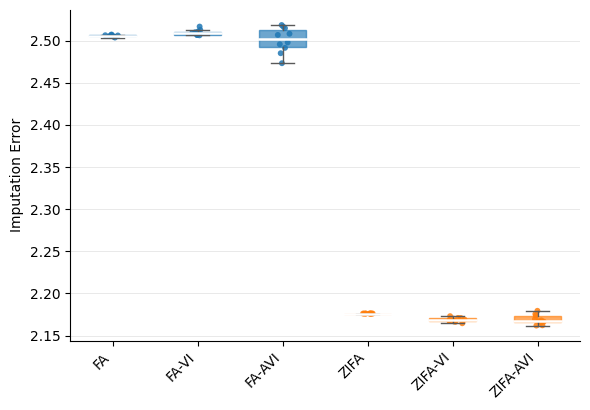

In [12]:
assign_loaded_performance_results()
df_imputation = metric_dataframe(results_imputation_fa, results_imputation_zifa, "Imputation Error")
ax = plot_metric(df_imputation, "Imputation Error")
ax.figure.tight_layout()
ax.figure.savefig(FIGURE_DIR / "performance_imputation_error.png", dpi=300, bbox_inches="tight")
ax.figure.savefig(FIGURE_DIR / "performance_imputation_error.pdf", bbox_inches="tight")
plt.show()


Loaded performance CSV results:
  ../results/scPI/performance_imputation_values.csv
  ../results/scPI/performance_clustering_values.csv


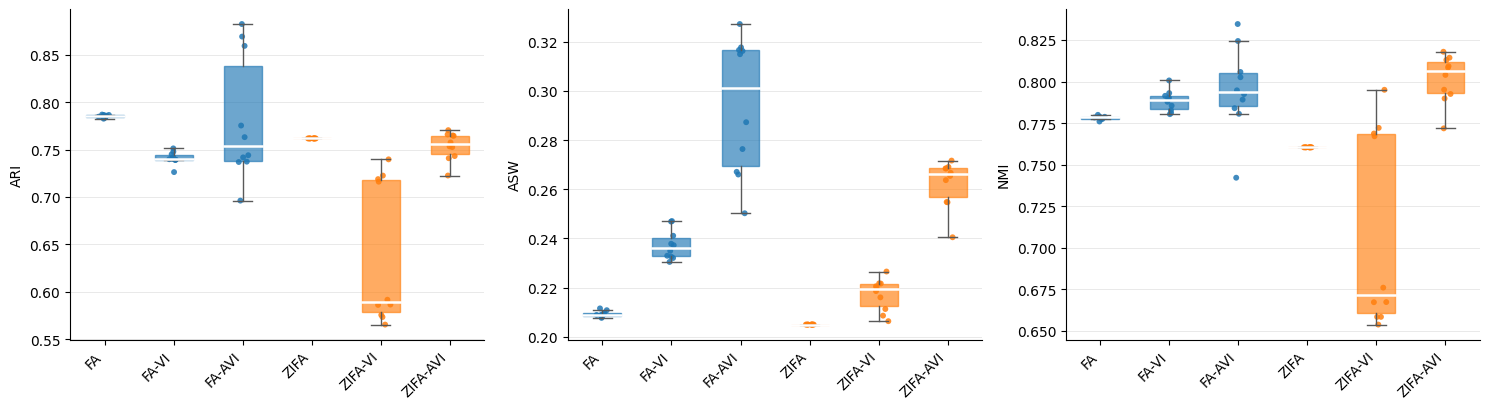

In [13]:
assign_loaded_performance_results()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, metric in zip(axes, ["ARI", "ASW", "NMI"]):
    df_metric = metric_dataframe(results_clustering_fa, results_clustering_zifa, metric)
    plot_metric(df_metric, metric, ax=ax)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "performance_clustering_metrics.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "performance_clustering_metrics.pdf", bbox_inches="tight")
plt.show()


Loaded performance CSV results:
  ../results/scPI/performance_imputation_values.csv
  ../results/scPI/performance_clustering_values.csv


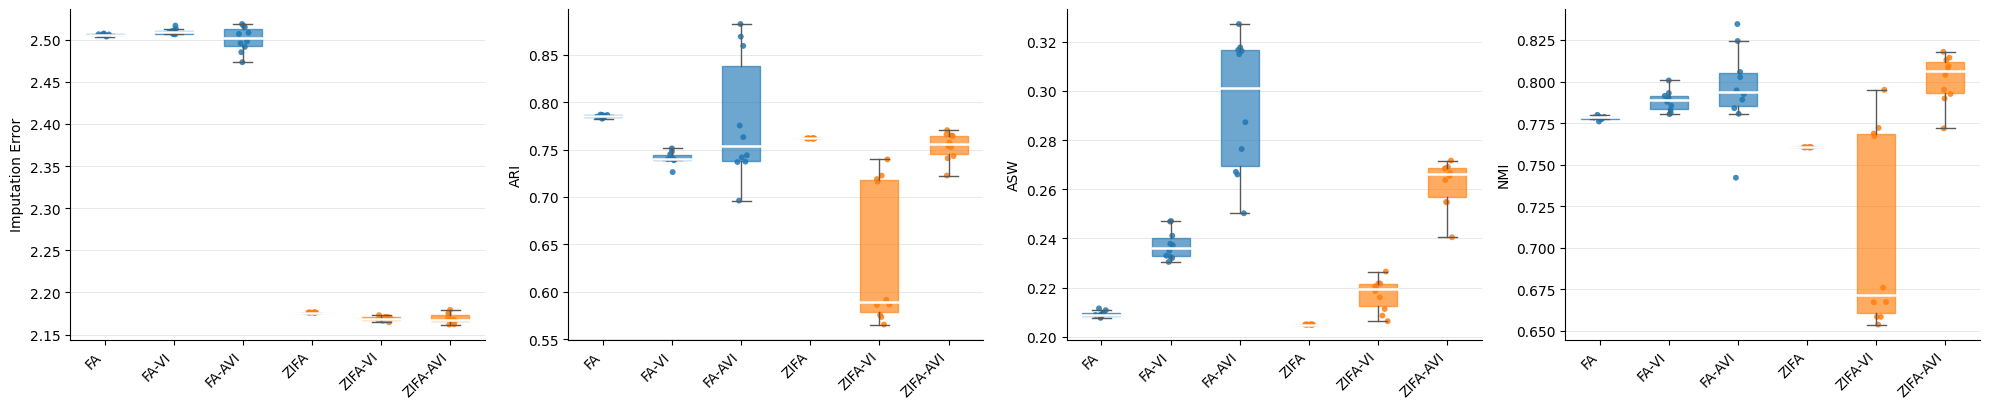

In [14]:
assign_loaded_performance_results()
df_imputation = metric_dataframe(results_imputation_fa, results_imputation_zifa, "Imputation Error")
fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))
plot_metric(df_imputation, "Imputation Error", ax=axes[0])
for ax, metric in zip(axes[1:], ["ARI", "ASW", "NMI"]):
    df_metric = metric_dataframe(results_clustering_fa, results_clustering_zifa, metric)
    plot_metric(df_metric, metric, ax=ax)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "performance_all_metrics.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "performance_all_metrics.pdf", bbox_inches="tight")
plt.show()
